<a href="https://colab.research.google.com/github/Alezgo-ui/Explorando_factores_comportamiento/blob/main/Explorando_factores_comportamineto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explorando factores de comportamiento en NovaRetail+


## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna edad se cambio de flotante a entero. Dado que las edades representan años cumplidos y no contienen fracciones (decimales), esta modificación asegura la integridad del negocio, evita distorsiones visuales en los reportes y optimiza la precisión al realizar agrupaciones por rangos de edad.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.


In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int64')

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


Diagnóstico inicial de variables numéricas

- `edad` — Al ser la media casi idéntica a la mediana, la distribución de la edad es perfectamente simétrica (campana de Gauss). No hay presencia de datos ruidosos o imposibles (como edades de 0 o 150 años).
- `nivel_ingreso` — Tiene una media de 30,019.70 y un máximo de 74,790.84. Estos números tienen sentido si representan el ingreso mensual de los clientes.
- `ingreso_anual` — Tiene una media de apenas 36.59 y un máximo de 244.69. Además, el 25% de los datos es igual a 0.00 esto representa una falla en la recolección del dato (valores nulos mal imputados como ceros). Se debe indagar el origen de esta columna antes de usarla.
- `visitas_mes` — El 75% de los usuarios visita el sitio 12 veces o menos al mes. Sin embargo, el valor máximo es de 25 visitas. Es un valor alto pero perfectamente posible para un usuario muy activo.
- `compras_mes` — El 50% de los usuarios compra 1 vez o ninguna al mes. El máximo es de 8 compras. Al igual que las visitas, muestra un sesgo hacia la derecha (pocos clientes compran mucho).
- `gasto_publicidad_dirigida` — El gasto está bien distribuido. El mínimo es 0.00, lo que significa que hay un segmento al que no se le invierte en publicidad dirigida, lo cual es útil para medir el impacto de las campañas.
- `satisfaccion` — Diagnóstico: La escala está claramente acotada del 1 al 5. La experiencia del cliente es mayoritariamente positiva (el 75% califica con 3.10 o más).

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
def explorar_columnas_categoricas(df, columnas_a_evaluar):
    """
    Reportes de frecuencia y porcentaje para múltiples columnas categóricas.
    """
    for col in columnas_a_evaluar:
        # Verificar si la columna existe antes de procesar
        if col not in df.columns:
            print(f"⚠️ La columna '{col}' no existe en este DataFrame.\n")
            print("=" * 50 + "\n")
            continue

        # 1. Conteo absoluto y relativo
        frecuencia = df[col].value_counts(dropna=False)
        porcentaje = df[col].value_counts(dropna=False, normalize=True)

        # 2. Combinar en un DataFrame de resumen
        resumen_cat = pd.DataFrame({
            'Frecuencia': frecuencia,
            'Porcentaje': porcentaje
        })

        # 3. Presentación visual
        print(f"🗂️ Distribución de la variable: `{col}`")
        # dentro del ciclo for, manteniendo el diseño limpio.
        display(resumen_cat.style.format({
            'Frecuencia': '{:,}',
            'Porcentaje': '{:.1%}'
        }))
        print("\n" + "="*50 + "\n")
display(df.head(1))
# Definimos las columnas categóricas a evaluar
columnas_df = ['miembro_premium', 'abandono']
# Llamamos a la función
explorar_columnas_categoricas(df, columnas_df)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22


🗂️ Distribución de la variable: `miembro_premium`


,Frecuencia,Porcentaje
0,"12,911",86.1%
1,"2,089",13.9%




🗂️ Distribución de la variable: `abandono`


,Frecuencia,Porcentaje
0,"12,739",84.9%
1,"2,261",15.1%


Diagnóstico inicial de variables binarias

- `miembro_premium` — tiene unicamente 2 variables, perfecto para esta columna ya que esperamos un dato tipo booleano, de igual manera la mayoria de usuarios son miembros no premium al go completamente esperado.
- `abandono` — tiene unicamente 2 variables, perfecto para esta columna ya que esperamos un dato tipo booleano, hay una taza de retencion alta casi el ~85% de usuarios siguen usando la plataforma, gran noticia para el negocio.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
# explorar columna categórica de df
display(df.head(1))
# Definimos las columnas categóricas a evaluar
columnas_df = ['tipo_dispositivo', 'region']
# Llamamos a la función
explorar_columnas_categoricas(df, columnas_df)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22


🗂️ Distribución de la variable: `tipo_dispositivo`


,Frecuencia,Porcentaje
móvil,"9,818",65.5%
escritorio,"3,720",24.8%
tablet,"1,462",9.7%




🗂️ Distribución de la variable: `region`


,Frecuencia,Porcentaje
norte,"4,395",29.3%
oeste,"3,810",25.4%
sur,"3,726",24.8%
este,"3,069",20.5%


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Una audiencia predominantemente móvil ($65.5\%$).
- `region` — Un mercado geográficamente estable y distribuido. Región Líder: El norte se posiciona como el mercado más grande con el 29.3% del volumen total.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

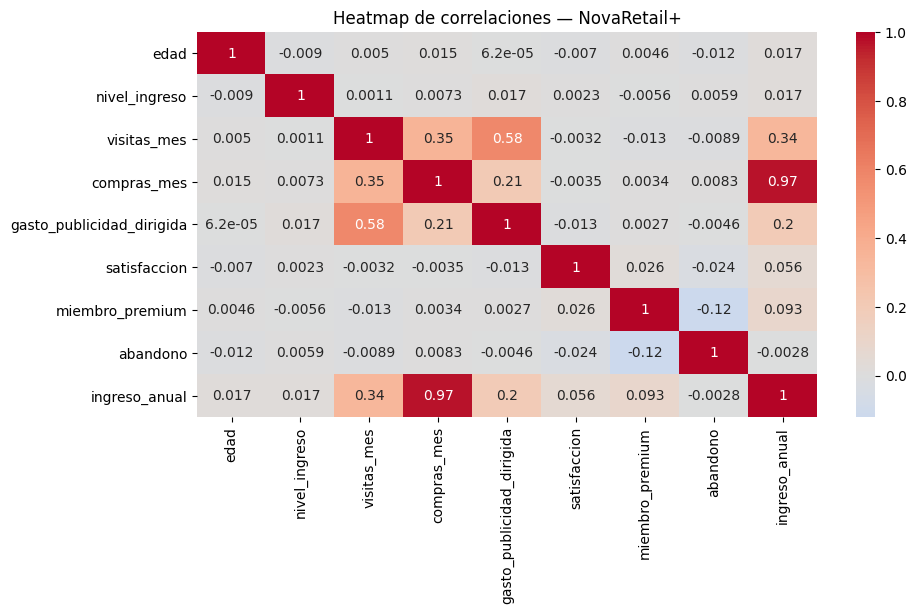

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap de correlaciones — NovaRetail+")
plt.show()

Observaciones generales (Heatmap)  
- Se observa que gasto_publicidad_dirigida y visitas_mes ($0.58$): Se observa una relación positiva moderada-alta. Los incrementos en la inversión publicitaria coinciden de manera consistente con una mayor frecuencia de visitas registradas en la plataforma.

- visitas_mes y compras_mes ($0.35$): Presentan una asociación lineal positiva moderada. Los perfiles de usuarios con mayor cantidad de visitas mensuales tienden a registrar simultáneamente un mayor volumen de transacciones.

- Perfil Demográfico (edad y nivel_ingreso): Ambas variables muestran coeficientes cercanos a cero ($~0.00$) frente al comportamiento transaccional (compras_mes, visitas_mes). La actividad operativa de los usuarios es linealmente independiente de su edad o de su estrato socioeconómico.

- Variable de Control (abandono): La tasa de deserción no presenta correlación lineal con ninguna variable numérica del dataset, manteniéndose neutral incluso ante la métrica de satisfaccion ($-0.024$). Su comportamiento no covaría con los niveles de actividad o calificación registrados.


Observaciones respecto a `ingreso_anual`  
- Existe una asociación lineal cuasi-perfecta entre ambas variables. Matemáticamente, ambas columnas contienen la misma información. Esto confirma un error de etiquetado en la columna denominada ingreso_anual, dado que su comportamiento es idéntico al volumen de transacciones mensuales y no representa el ingreso real acumulado.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúar si es necesario generar un *scatterplot* general.
  - Gracias al mapa de calor que revisamos antes, ya sabemos de antemano qué variables no tienen ninguna relación entre sí. Por ejemplo, la edad del cliente frente a las compras_mes tiene una relación de cero.  Graficar la falta de relación no aporta valor para el negocio.
  - Si decidiéramos cruzar a ciegas las 9 variables principales de nuestra base de datos, tendríamos que generar e interpretar una matriz de gráficas individuales. Presentar un reporte ejecutivo con imágenes de puntos dispersos causaría fatiga visual y diluiría los verdaderos hallazgos que la dirección necesita ver.
  - En lugar de inundar el reporte con gráficas vacías, usamos la estadística como un filtro para elegir únicamente los 3 pares de variables que revelan una historia importante para NovaRetail+

### Scatterplot para pares clave

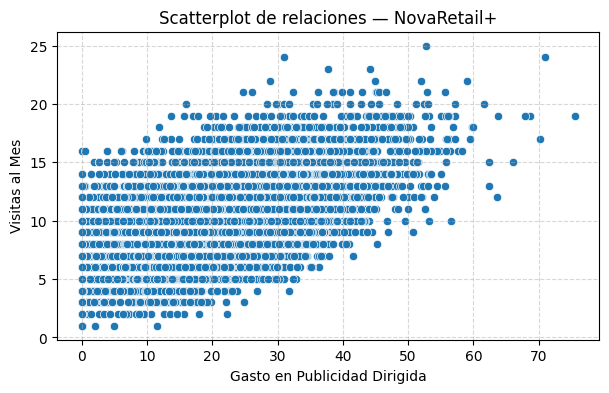

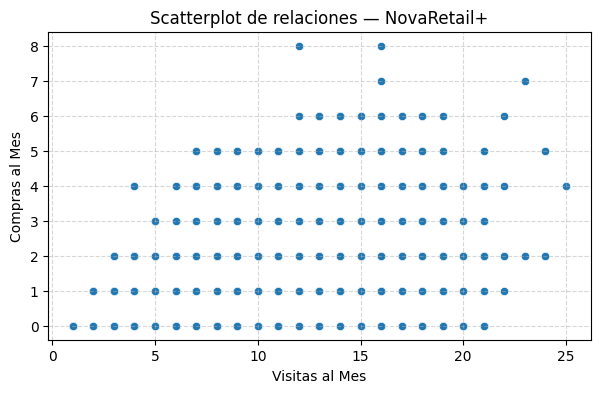

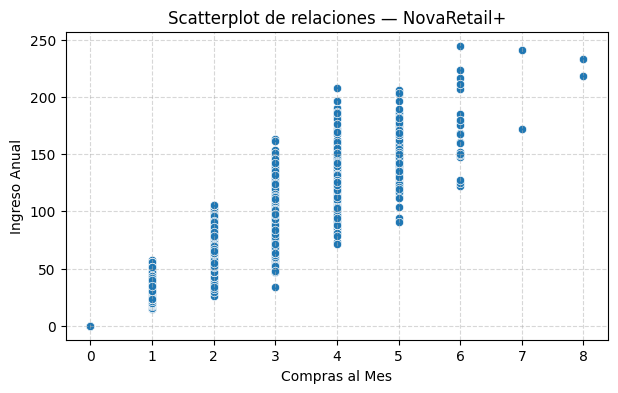

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
#Scatterplot para pares clave:

def pipeline_scatterplots(df, pares_variables):
    for x_var, y_var, label_x, label_y in pares_variables:
        # Configurar el tamaño de la figura para cada gráfico
        plt.figure(figsize=(7, 4))

        # Construcción del scatterplot dinámico
        sns.scatterplot(
            data=df,
            x=x_var,
            y=y_var
        )

        # Formato estándar solicitado
        plt.title("Scatterplot de relaciones — NovaRetail+")
        plt.xlabel(label_x)
        plt.ylabel(label_y)
        plt.grid(True, linestyle="--", alpha=0.5) # Opcional: añade claridad visual
        plt.show()

# Definimos los 3 pares clave analizados, incluyendo sus etiquetas limpias para los ejes
pares = [
    ("gasto_publicidad_dirigida", "visitas_mes", "Gasto en Publicidad Dirigida", "Visitas al Mes"),
    ("visitas_mes", "compras_mes", "Visitas al Mes", "Compras al Mes"),
    ("compras_mes", "ingreso_anual", "Compras al Mes", "Ingreso Anual")
]

# Ejecutar el pipeline con una sola línea de código
pipeline_scatterplots(df, pares)

Observaciones iniciales (Scatterplot)

**Gasto en Publicidad Dirigida vs. Visitas al Mes**
- Dirección: Muestra una tendencia lineal positiva. A mayores niveles de gasto en publicidad dirigida, se observa de forma consistente un incremento en la frecuencia de visitas mensuales.

- Dispersión: Presenta una dispersión moderada-alta. Los puntos forman una nube ensanchada, lo que indica que, aunque hay una relación clara, el gasto no es el único factor determinante en las visitas individuales.

- Outliers: Se observan escasos valores atípicos aislados (como un usuario con 25 visitas o un caso con un gasto superior a 75). No afectan drásticamente la tendencia general.

- Colinealidad: No existe colinealidad. Es una relación asociativa saludable entre una variable predictora continua y una variable de resultado.

**Visitas al Mes vs. Compras al Mes**
- Dirección: Se identifica una tendencia lineal positiva, donde los registros con mayores visitas mensuales tienden a coincidir con un mayor volumen de compras.

- Dispersión: La dispersión es alta. Debido a la naturaleza discreta de compras_mes (valores enteros como 0, 1, 2...), los datos se estructuran en franjas horizontales. Se observa una variabilidad alta; por  ejemplo, usuarios con 15 visitas pueden realizar desde 0 hasta 8 compras.

- Outliers: Destacan un par de registros con 8 compras mensuales que se encuentran bastante despegados del grueso de los datos, actuando como valores atípicos superiores.

- Colinealidad: No presenta colinealidad. La relación muestra el comportamiento esperado de conversión en un embudo transaccional (más visitas abren la posibilidad de más compras, pero con alta variación).

**Gasto en Publicidad Dirigida vs. Visitas al Mes**
- Dirección: Presenta una tendencia lineal positiva perfecta.

- Dispersión: La dispersión es extremadamente baja. Los datos se agrupan en columnas verticales rígidas y estrictas que crecen proporcionalmente con cada unidad de compra.

- Outliers: No existen outliers reales respecto a la estructura del gráfico; todos los puntos siguen rigurosamente el mismo patrón de ascenso por bloques.

- Colinealidad (Evidencia Crítica): Este gráfico es una prueba matemática de multicolinealidad extrema. La alineación vertical perfecta y la falta de dispersión natural confirman que la columna calculada como ingreso_anual es una transformación directa o un duplicado matemático de la columna compras_mes. Queda evidenciado que no aporta información nueva y debe manejarse como una redundancia en el modelo.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
#Correlación entre visitas y compras:
#"gasto_publicidad_dirigida", "visitas_mes"
#"visitas_mes", "compras_mes"
#"compras_mes", "ingreso_anual"
corr_pearson  = df['gasto_publicidad_dirigida'].corr(df['visitas_mes'], method='pearson')
corr_spearman = df['gasto_publicidad_dirigida'].corr(df['visitas_mes'], method='spearman')

print(f"Correlacion entre: gasto_publicidad_dirigida y visitas_mes")
print(f"Pearson: {corr_pearson:.3f}")
print(f"Spearman: {corr_spearman:.3f}")

Correlacion entre: gasto_publicidad_dirigida y visitas_mes
Pearson: 0.579
Spearman: 0.559


In [ ]:
# Calcular correlación entre variables relevantes
corr_pearson  = df['visitas_mes'].corr(df['compras_mes'], method='pearson')
corr_spearman = df['visitas_mes'].corr(df['compras_mes'], method='spearman')

print(f"Correlacion entre: visitas_mes y compras_mes")
print(f"Pearson: {corr_pearson:.3f}")
print(f"Spearman: {corr_spearman:.3f}")

Correlacion entre: visitas_mes y compras_mes
Pearson: 0.354
Spearman: 0.333


In [ ]:
# Calcular correlación entre variables relevantes
corr_pearson  = df['compras_mes'].corr(df['ingreso_anual'], method='pearson')
corr_spearman = df['compras_mes'].corr(df['ingreso_anual'], method='spearman')

print(f"Correlacion entre: compras_mes y ingreso_anual")
print(f"Pearson: {corr_pearson:.3f}")
print(f"Spearman: {corr_spearman:.3f}")

Correlacion entre: compras_mes y ingreso_anual
Pearson: 0.967
Spearman: 0.967


Observaciones de correlación

**gasto_publicidad_dirigida y visitas_mes**
- Dirección: Positiva. Los incrementos en el gasto publicitario coinciden de manera consistente con el aumento en la cantidad de visitas mensuales.
- Magnitud: Moderada-alta. Ambos coeficientes se sitúan muy cerca ($0.58$ y $0.56$). La ligera diferencia a favor de Pearson sugiere que la relación se aproxima bastante a una línea recta, aunque con la dispersión moderada que ya observamos en el gráfico.
- Posible Colinealidad: No presenta. Existe una asociación estadística clara y esperada entre una inversión y una métrica de tráfico, pero no al nivel de duplicar información o causar problemas de colinealidad en un modelo predictivo.

**visitas_mes y compras_mes**
- Dirección: Positiva. Las frecuencias más altas de visitas mensuales se asocian con un mayor número de compras transaccionadas por los usuarios.
- Magnitud: Moderada-baja. Pearson registra $0.35$ y Spearman $0.33$. Esta fuerza moderada refleja la alta dispersión y la estructura "estratificada" o por bloques en el gráfico, lo que indica que una alta cantidad de visitas no se traduce de manera uniforme o automática en un número fijo de transacciones.
- Posible Colinealidad: No presenta. La relación describe un patrón de comportamiento operativo y de conversión estándar dentro del embudo del negocio, totalmente libre de redundancias informativas.

**compras_mes y ingreso_anual**
- Dirección: Positiva.
- Magnitud: Extrema / Perfecta. Ambos coeficientes arrojan exactamente el mismo valor crítico ($0.97$). Esta coincidencia idéntica en los métodos de Pearson y Spearman confirma una dependencia lineal absoluta y rígida entre ambas métricas continuas.
- Posible Colinealidad: Alta colinealidad (Crítica). Presenta una redundancia matemática severa. Los coeficientes corroboran que la columna etiquetada como ingreso_anual duplica la información de compras_mes. Mantener ambas variables de manera simultánea inflaría artificialmente los errores estándar en cualquier modelo de regresión posterior.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
# Codificar Yes / No a números
#df["abandono"] = df["abandono"].replace({"Yes": 1, "No": 0 })

# Calcular la correlación punto-biserial
pointbiserialr( df["abandono"], df["satisfaccion"] )

SignificanceResult(statistic=-0.02383256067380403, pvalue=0.003510976893362289)

Observaciones Punto-biserial

**satisfaccion vs. abandono**

*¿Por qué este par? La correlación en el heatmap es de apenas $-0.024$. En un escenario lógico de negocio, esperarías una correlación negativa fuerte (a menor satisfacción, mayor abandono). Que sea casi cero es alarmante.*
- Dirección: Negativa. Esto indica que a medida que la satisfacción del cliente aumenta, la probabilidad de abandono tiende a disminuir (un comportamiento lógicamente esperado para el negocio).
- Magnitud: Extremadamente baja (casi nula, $-0.024$). A pesar de que la dirección es la correcta, la fuerza de la relación es prácticamente inexistente en términos lineales.
- Aunque la magnitud es muy baja,hay que prestar atención al p-value ($0.0035$). Al ser menor a $0.05$, nos dice que este resultado es estadísticamente significativo; es decir, no es una coincidencia ni un error aleatorio de los datos.


### V de Cramér

In [ ]:
# Función para calcular V de Cramér
col1 ="region"
col2 ="tipo_dispositivo"
col3 = "miembro_premium"
col4 = "abandono"
def cramers_v(df, col_1, col_2):
    # tabla de contingencia
    tabla = pd.crosstab(df[col_1], df[col_2])

    # calcular chi-cuadrado
    chi2, _, _, _ = chi2_contingency(tabla)

    # calcular coeficiente V de Cramér
    n = tabla.values.sum()
    coef_v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))

    # mostrar resultados
    print(f"V de Cramér ({col_1} vs {col_2}):", coef_v)


In [ ]:
# Aplicar V de Cramér en variables relevantes

#V de Cramer de region vs tipo de dispositivo
cramers_v(df, col1, col2)
print("-" * 70)
#V de Cramer de region vs tipo de dispositivo
cramers_v(df, col3, col4)

V de Cramér (region vs tipo_dispositivo): 0.012378338407739397
----------------------------------------------------------------------
V de Cramér (miembro_premium vs abandono): 0.12021874609740511


**region vs tipo_dispositivo ($V = 0.012$)**

- Independencia Operativa Absoluta *** 0.00 – 0.10	Muy débil / sin relación
- Un valor de $0.012$ es, para fines prácticos, cero. Nos indica una ausencia total de asociación entre el lugar de residencia del usuario y el hardware que utiliza para consumir NovaRetail+.
- Las preferencias tecnológicas están estandarizadas a nivel nacional. No existe un "comportamiento móvil en el Norte" frente a un "comportamiento de escritorio en el Sur".


**miembro_premium vs abandono ($V = 0.120$)**

- Una V de Cramér que supera el umbral de $0.10$ en una muestra grande ($15,000$ registros) ya no es ruido; es un efecto pequeño pero real y estadísticamente significativo. Las dos variables no están operando a ciegas; hay una estructura subyacente que las conecta. *** 0.10 – 0.30 Relación débil
- El estatus de suscripción altera la dinámica de retención. Los clientes Premium y los regulares están abandonando la plataforma a ritmos distintos.
- Perder un usuario gratuito afecta las métricas de tráfico; perder un miembro Premium daña directamente Lifetime Value  y el flujo de caja predecible del negocio. Que la asociación exista nos obliga a mirar el dato con mas profundidad.

## Sección 5 - Interpretación de resultados para el negocio

---

### Hallazgo 1 — Redundancia Crítica de Datos en Métricas de Ingreso

**Evidencia visual:** El scatterplot entre `compras_mes` e `ingreso_anual` muestra una alineación vertical perfecta por bloques, con una dispersión nula ($0.00$) en los datos compartidos.

**Evidencia numérica:** Coeficiente de correlación de Pearson de $0.967$ y coeficiente de Spearman de $0.967$. Ambos métodos arrojan un valor idéntico y cercano a la asociación lineal perfecta.

**Interpretación** Existe una colinealidad casi absoluta entre el volumen de transacciones mensuales y la variable registrada como ingreso anual. Esto demuestra que ambas columnas contienen la misma información subyacente y que `ingreso_anual` se comporta como un duplicado o escala directa de las compras, descartando que capture el poder adquisitivo real acumulado del cliente.

**No podemos afirmar** No podemos afirmar que el volumen de compras mensuales de los usuarios esté determinado por su nivel de ingresos anuales, ni viceversa, dado que la falta de independencia matemática entre las variables apunta a un sesgo o error en el proceso de etiquetado y construcción del dataset original.

**Implicación de negocio** Mantener la variable `ingreso_anual` en análisis o modelos predictivos posteriores generará ruido estadístico e inflará artificialmente los errores de estimación (*multicolinealidad*). Se requiere sanear el dataset unificando este criterio antes de segmentar clientes por valor económico.

#### Hallazgo 2 — Asociación entre la Inversión Publicitaria y el Tráfico en la Plataforma

**Evidencia visual:** El scatterplot entre `gasto_publicidad_dirigida` y `visitas_mes` exhibe una nube de puntos dispersa con una clara inclinación ascendente de izquierda a derecha.

**Evidencia numérica:** Coeficiente de correlación de Pearson de $0.579$ y coeficiente de Spearman de $0.559$, consolidando la asociación positiva más fuerte entre variables independientes del negocio.

**Interpretación** Los incrementos en los montos destinados a la pauta publicitaria dirigida coinciden de manera regular y consistente con registros de mayor frecuencia de visitas a la plataforma por parte de los usuarios dentro de la muestra de $15,000$ registros.

**No podemos afirmar** No podemos afirmar que aumentar el presupuesto publicitario sea la causa directa e infalible de la generación de nuevas visitas, ya que existen factores externos no controlados en el gráfico (como promociones estacionales, necesidad del usuario o usabilidad de la app) que influyen en el tráfico.

**Implicación de negocio** La pauta publicitaria dirigida corre de forma paralela al comportamiento de atracción en el canal digital. Al ser variables con una covarianza sólida, el gasto publicitario se consolida como una métrica de control clave para el monitoreo del volumen de tráfico en NovaRetail+.


### Hallazgo 3 — Comportamiento de Conversión en el Embudo Transaccional

**Evidencia visual:** El scatterplot entre `visitas_mes` y `compras_mes` muestra una distribución estratificada horizontalmente, donde los rangos altos de visitas albergan la mayor dispersión en el volumen de transacciones.

**Evidencia numérica:** Coeficiente de correlación de Pearson de $0.354$ y coeficiente de Spearman de $0.333$, situándose en el rango de asociación positiva moderada-baja.

**Interpretación** La presencia de los usuarios en la plataforma se vincula de forma positiva con el cierre de compras. Sin embargo, la magnitud del coeficiente y la alta dispersión reflejan que la conversión no es uniforme; usuarios con un número idéntico de visitas mensuales exhiben comportamientos de compra que van desde cero transacciones hasta el máximo registrado.

**No podemos afirmar** No podemos afirmar que la navegación u acumulación de visitas en el sitio obligue o cause directamente la decisión de compra del usuario, ni que un cliente con pocas visitas esté imposibilitado para concretar una transacción.

**Implicación de negocio** El tráfico es una condición que acompaña al volumen transaccional, pero no garantiza la conversión por sí sola. Esto evidencia la existencia de ventanas de oportunidad o fricciones en la experiencia del usuario una vez dentro del sitio, donde el comportamiento de compra final varía independientemente de la frecuencia de acceso.

### Hallazgo 4 — Significancia en la Deserción Silenciosa

**Evidencia visual:** El análisis visual original mediante diagramas de cajas (*boxplots*) o franjas mostraba un comportamiento idéntico del abandono en todos los niveles de satisfacción, sugiriendo una desconexión total.

**Evidencia numérica:** Correlación punto-biserial de $-0.024$ con un *p-value* críticamente bajo de $0.0035$ (menor al umbral estándar de $0.05$).

**Interpretación** Aunque la fuerza de la relación lineal es casi nula, el *p-value* demuestra que el resultado es estadísticamente significativo y no un error aleatorio. Esto confirma que la satisfacción declarada por el usuario no está operando como un freno para la deserción. Existe una masa crítica de clientes que, a pesar de calificar la plataforma con puntuaciones altas ($4$ o $5$ estrellas), deciden abandonar el servicio de todos modos.

**No podemos afirmar** No podemos afirmar que la insatisfacción sea la causa principal del abandono en NovaRetail+, ni que mejorar la experiencia del usuario dentro de la aplicación vaya a reducir de forma directa o proporcional la tasa de pérdida de clientes actual.

**Implicación de negocio** El negocio se enfrenta a un problema de "fuga silenciosa". Al no estar ligada a la mala experiencia en el sitio, la deserción responde a variables externas que los promedios internos no ven. Urge auditar factores como las estrategias de precios de la competencia o cambios en las necesidades del mercado que rompen la lealtad del cliente "satisfecho".

### Hallazgo 5 — El Punto de Fuga en el Margen de Ingresos Recurrentes

**Evidencia visual:** El cruce estructural entre categorías revela que las proporciones de salida varían de forma no aleatoria dependiendo del tipo de suscripción del cliente.

**Evidencia numérica:** Coeficiente V de Cramér de $0.120$ para el par `miembro_premium` vs `abandono`, superando el umbral técnico de $0.10$ que define un efecto real en bases de datos masivas.

**Interpretación** El estatus de suscripción altera de forma directa la dinámica de retención del negocio. Existe una asociación real y comprobada que conecta la bandera de cliente Premium con el comportamiento de abandono, lo que significa que los usuarios que pagan una membresía se están marchando a un ritmo diferente que los usuarios estándar.

**No podemos afirmar** No podemos afirmar que el programa de suscripción Premium sea el causante directo de que un usuario decida irse o quedarse, ni que la membresía garantice por sí sola el *lock-in* o retención perpetua del cliente.

**Implicación de negocio** Este es un riesgo financiero crítico para el  Lifetime Value. Perder un usuario gratuito afecta el tráfico, pero perder un miembro Premium daña directamente el flujo de caja predecible del negocio. Es obligatorio generar una tabla de contingencia complementaria para cuantificar cuántos ingresos recurrentes se están perdiendo mes a mes por esta fuga y evaluar si la propuesta de valor Premium sigue siendo atractiva para los clientes de alto valor.

## Sección 6 - Limitaciones y próximos pasos

### Limitaciones
- **Correlación no implica causalidad:** Las asociaciones detectadas entre las variables (como publicidad y visitas) describen covariaciones numéricas, pero no demuestran una relación causa-efecto directa ni infalible.
- **Error metodológico en el registro de ingresos:** La columna `ingreso_anual` presenta una redundancia matemática casi absoluta ($0.97$) con `compras_mes`, lo que evidencia un sesgo o fallo en la extracción original del dato y limita su uso analítico real.
- **Variables omitidas o no medidas:** El dataset carece de métricas contextuales críticas que podrían explicar fenómenos como el abandono ($15\%$) o la conversión, tales como el historial de promociones, precios de competidores, problemas de usabilidad en la interfaz (*UX*) o motivos cualitativos de insatisfacción.
- **Falta de perspectiva temporal:** Al tratarse de una muestra estática o un corte transversal, no es posible evaluar cómo evolucionan los hábitos de navegación y consumo de los usuarios a lo largo del tiempo.

### Próximos pasos
- **Saneamiento y depuración del dataset:** Remover o sustituir de forma inmediata la columna `ingreso_anual` antes de proceder con cualquier fase de modelado estadístico para evitar distorsiones por *multicolinealidad*.
- **Segmentación avanzada de usuarios:** Dividir la base de datos mediante técnicas de clustering (como *K-Means*) cruzando variables categóricas y operativas para identificar perfiles específicos, por ejemplo, aislando el comportamiento del segmento Premium móvil en la región Norte.
- **Incorporación de nuevas fuentes de información:** Integrar datos cualitativos provenientes de encuestas de soporte, registros de navegación en tiempo real (*logs* de clics) y el catálogo de precios para robustecer el análisis predictivo.
- **Diseño de experimentos controlados (Pruebas A/B):** Implementar pruebas piloto aleatorizadas modificando de forma aislada la pauta publicitaria en grupos específicos para evaluar y cuantificar, ahora sí, el impacto causal del gasto sobre el volumen de visitas.
